In [59]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import zipfile
import librosa
import torch
import numpy as np
from SMT import *
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Get audio files from single person

In [60]:
# Update directory and zip names
AUDIO_DIR = Path("./data/LibriSpeech/dev-clean/84/121123")

def list_audio_files(audio_dir: Path):
    # Common audio extensions
    exts = (".wav", ".mp3", ".ogg", ".flac")
    return [p for p in sorted(audio_dir.iterdir()) if p.is_file() and p.suffix.lower() in exts]

audio_files = list_audio_files(AUDIO_DIR)

### Get mel/mfcc features from each file

In [61]:
out = extract_features_from_files(audio_files)

mels = [clip["mel_spectrogram"] for _, clip in out.items()]
mfccs = [clip["mfcc"] for _, clip in out.items()]
log_mels = [clip["log_mel_db"] for _, clip in out.items()]

hop_length = [clip["hop_length"] for _, clip in out.items()][0]
sr = [clip["sr"] for _, clip in out.items()][0]

print([a.shape for a in mels])

[(40, 210), (40, 400), (40, 1370), (40, 681), (40, 441), (40, 1597), (40, 563), (40, 201), (40, 702), (40, 270), (40, 720), (40, 326), (40, 257), (40, 241), (40, 289), (40, 304), (40, 842), (40, 938), (40, 356), (40, 244), (40, 693), (40, 482), (40, 262), (40, 469), (40, 1039), (40, 626), (40, 1395), (40, 308), (40, 477)]


### Plot example 

[Text(0.5, 1.0, 'MFCC')]

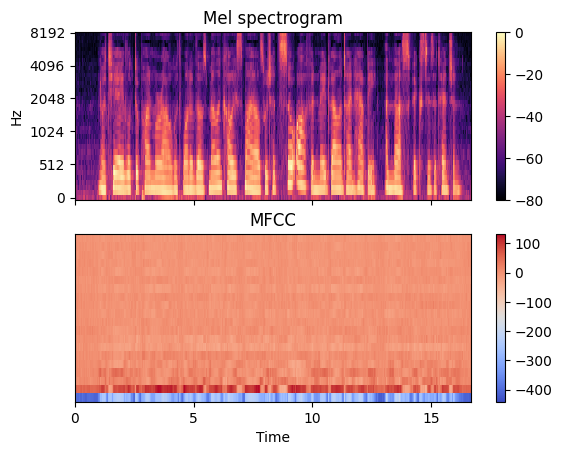

In [56]:
import matplotlib.pyplot as plt

idx = 10
fig, ax = plt.subplots(nrows=2, sharex=True)
img = librosa.display.specshow(log_mels[idx],x_axis='time', y_axis='mel', fmax=8000,ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()
img = librosa.display.specshow(mfccs[idx], x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])
ax[1].set(title='MFCC')

In [4]:
print(sr)
print(hop_length)

16000
160


### Patch the mfcc/mel representations

In [62]:
patches, utterance_bounds = patch_multiple_utterances(mels, sr, hop_length)

### Plot patches

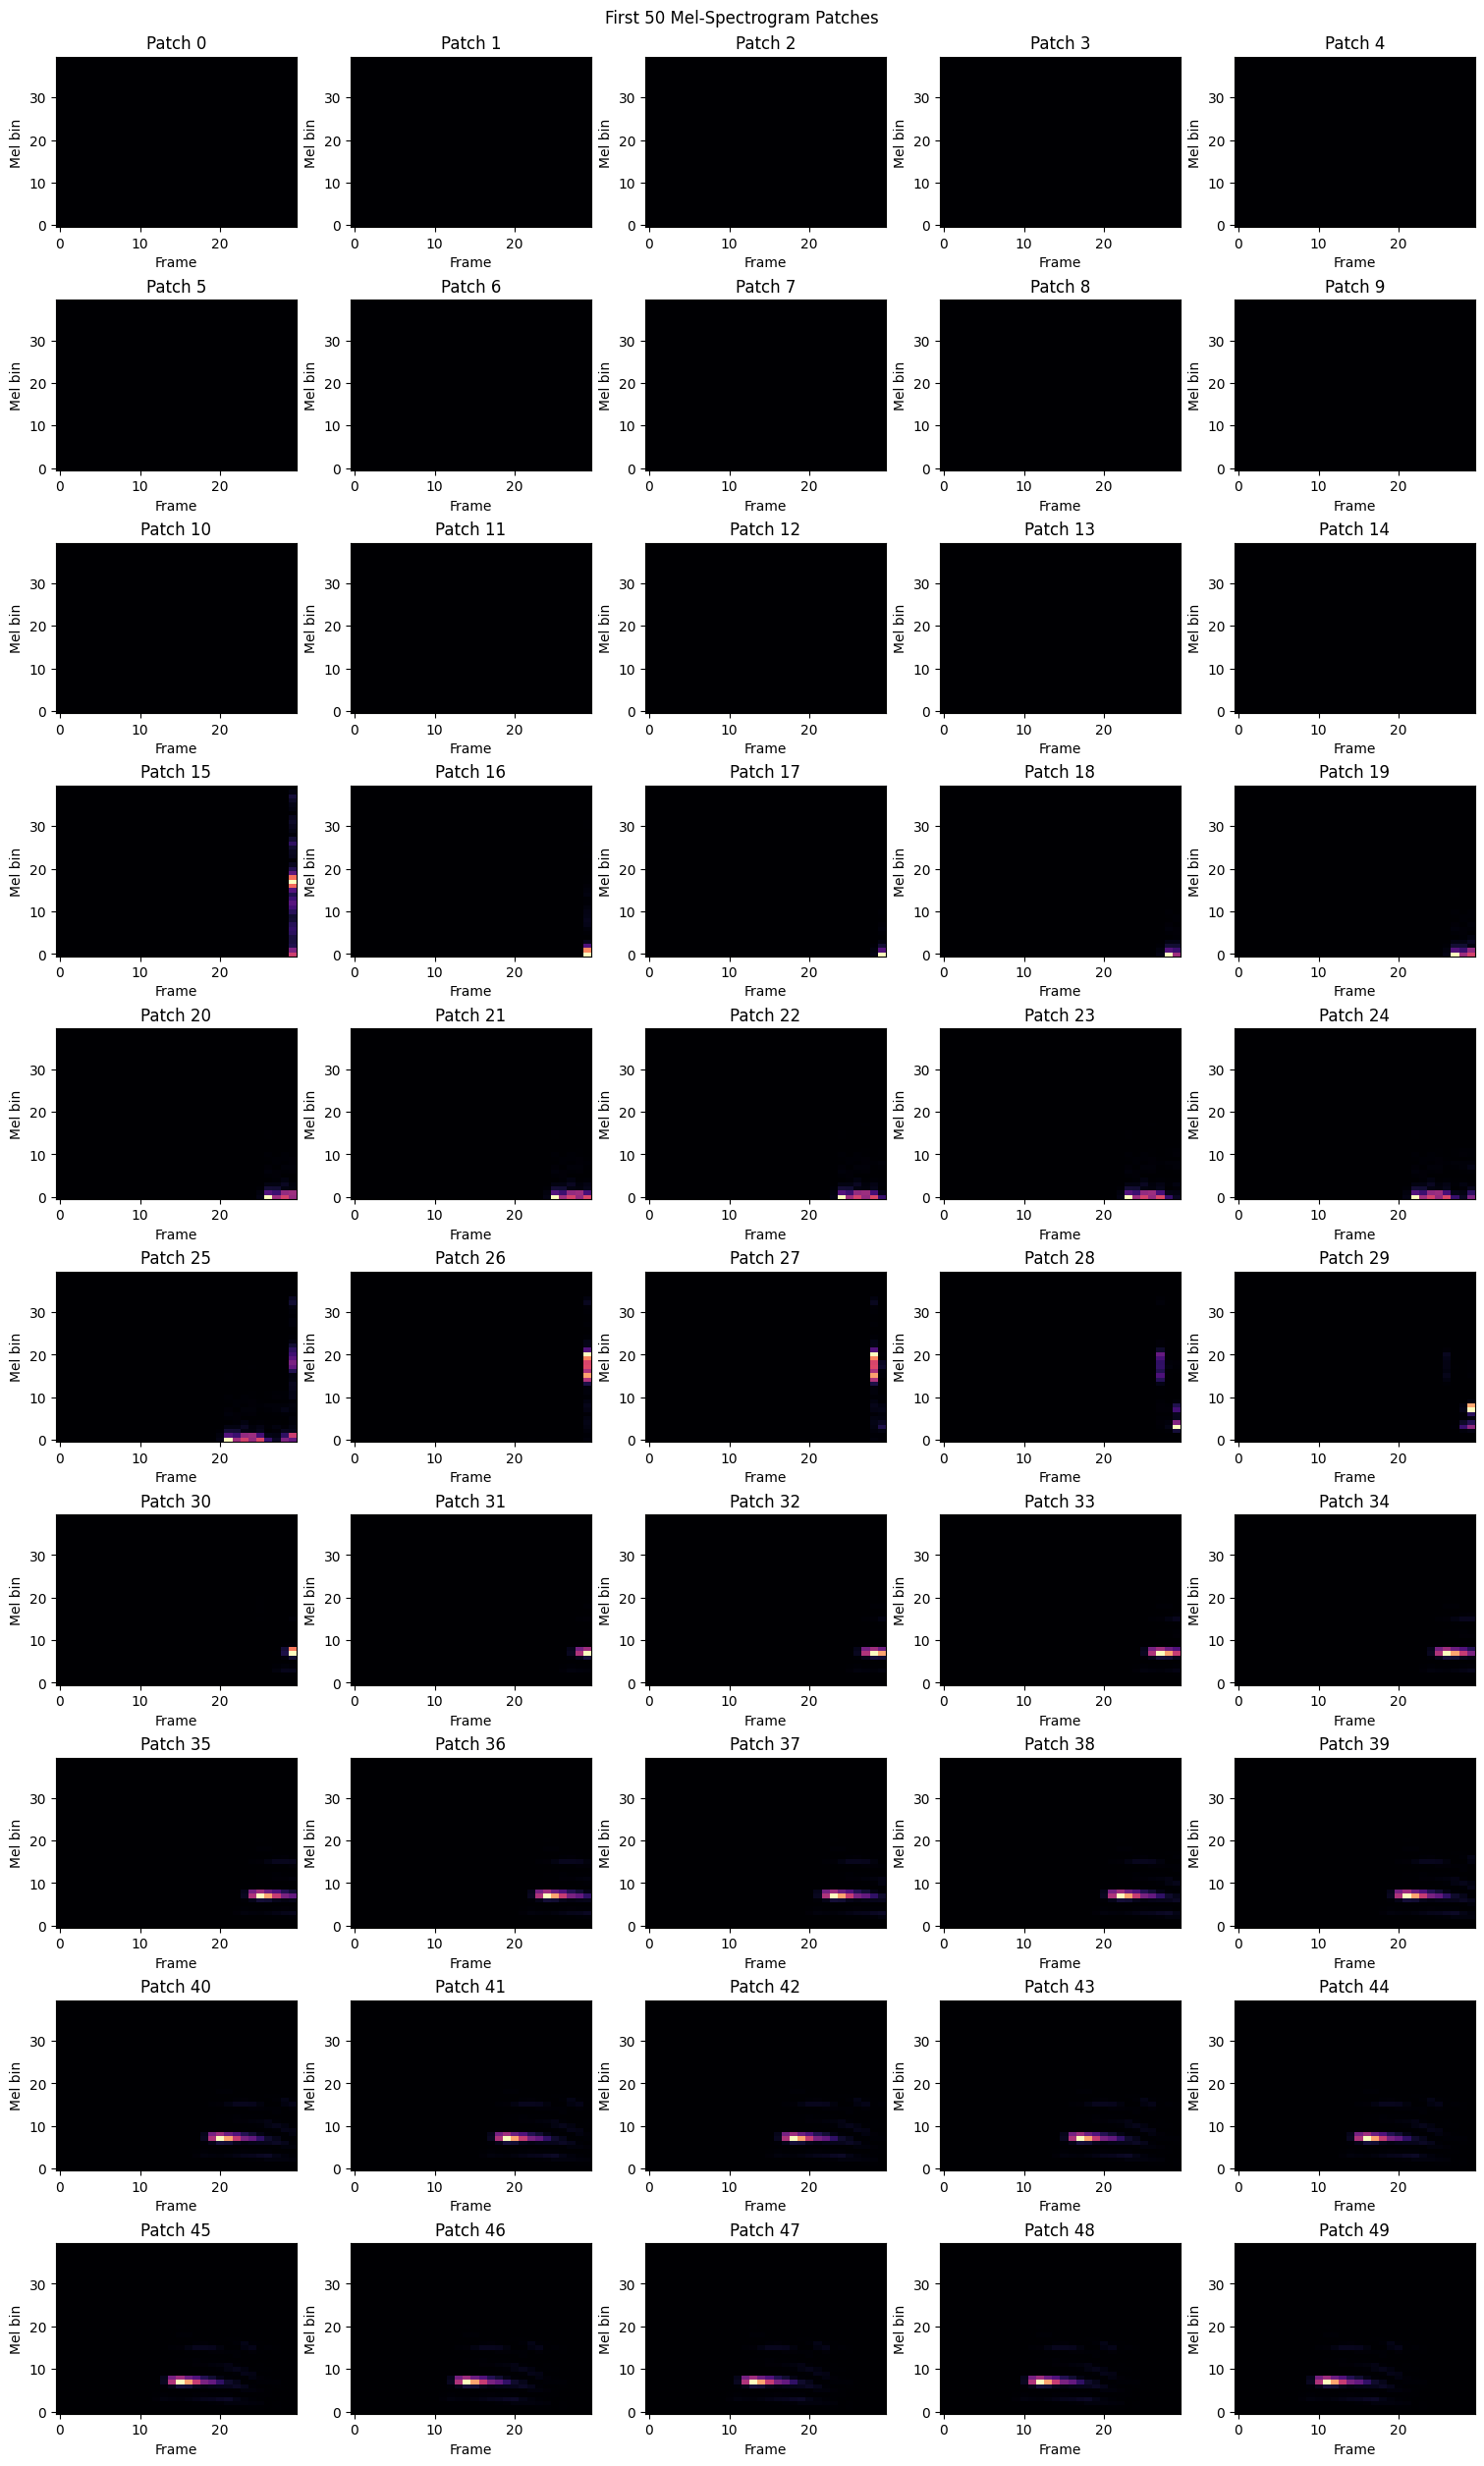

In [7]:
plot_first_n_mel_patches(patches.reshape(patches.shape[0], 40, 30), n_show=50, cols=5)

### Preprocess and plot patches again

In [63]:
norm_patches, mean, zcaMatrix = preprocess_patches(patches)

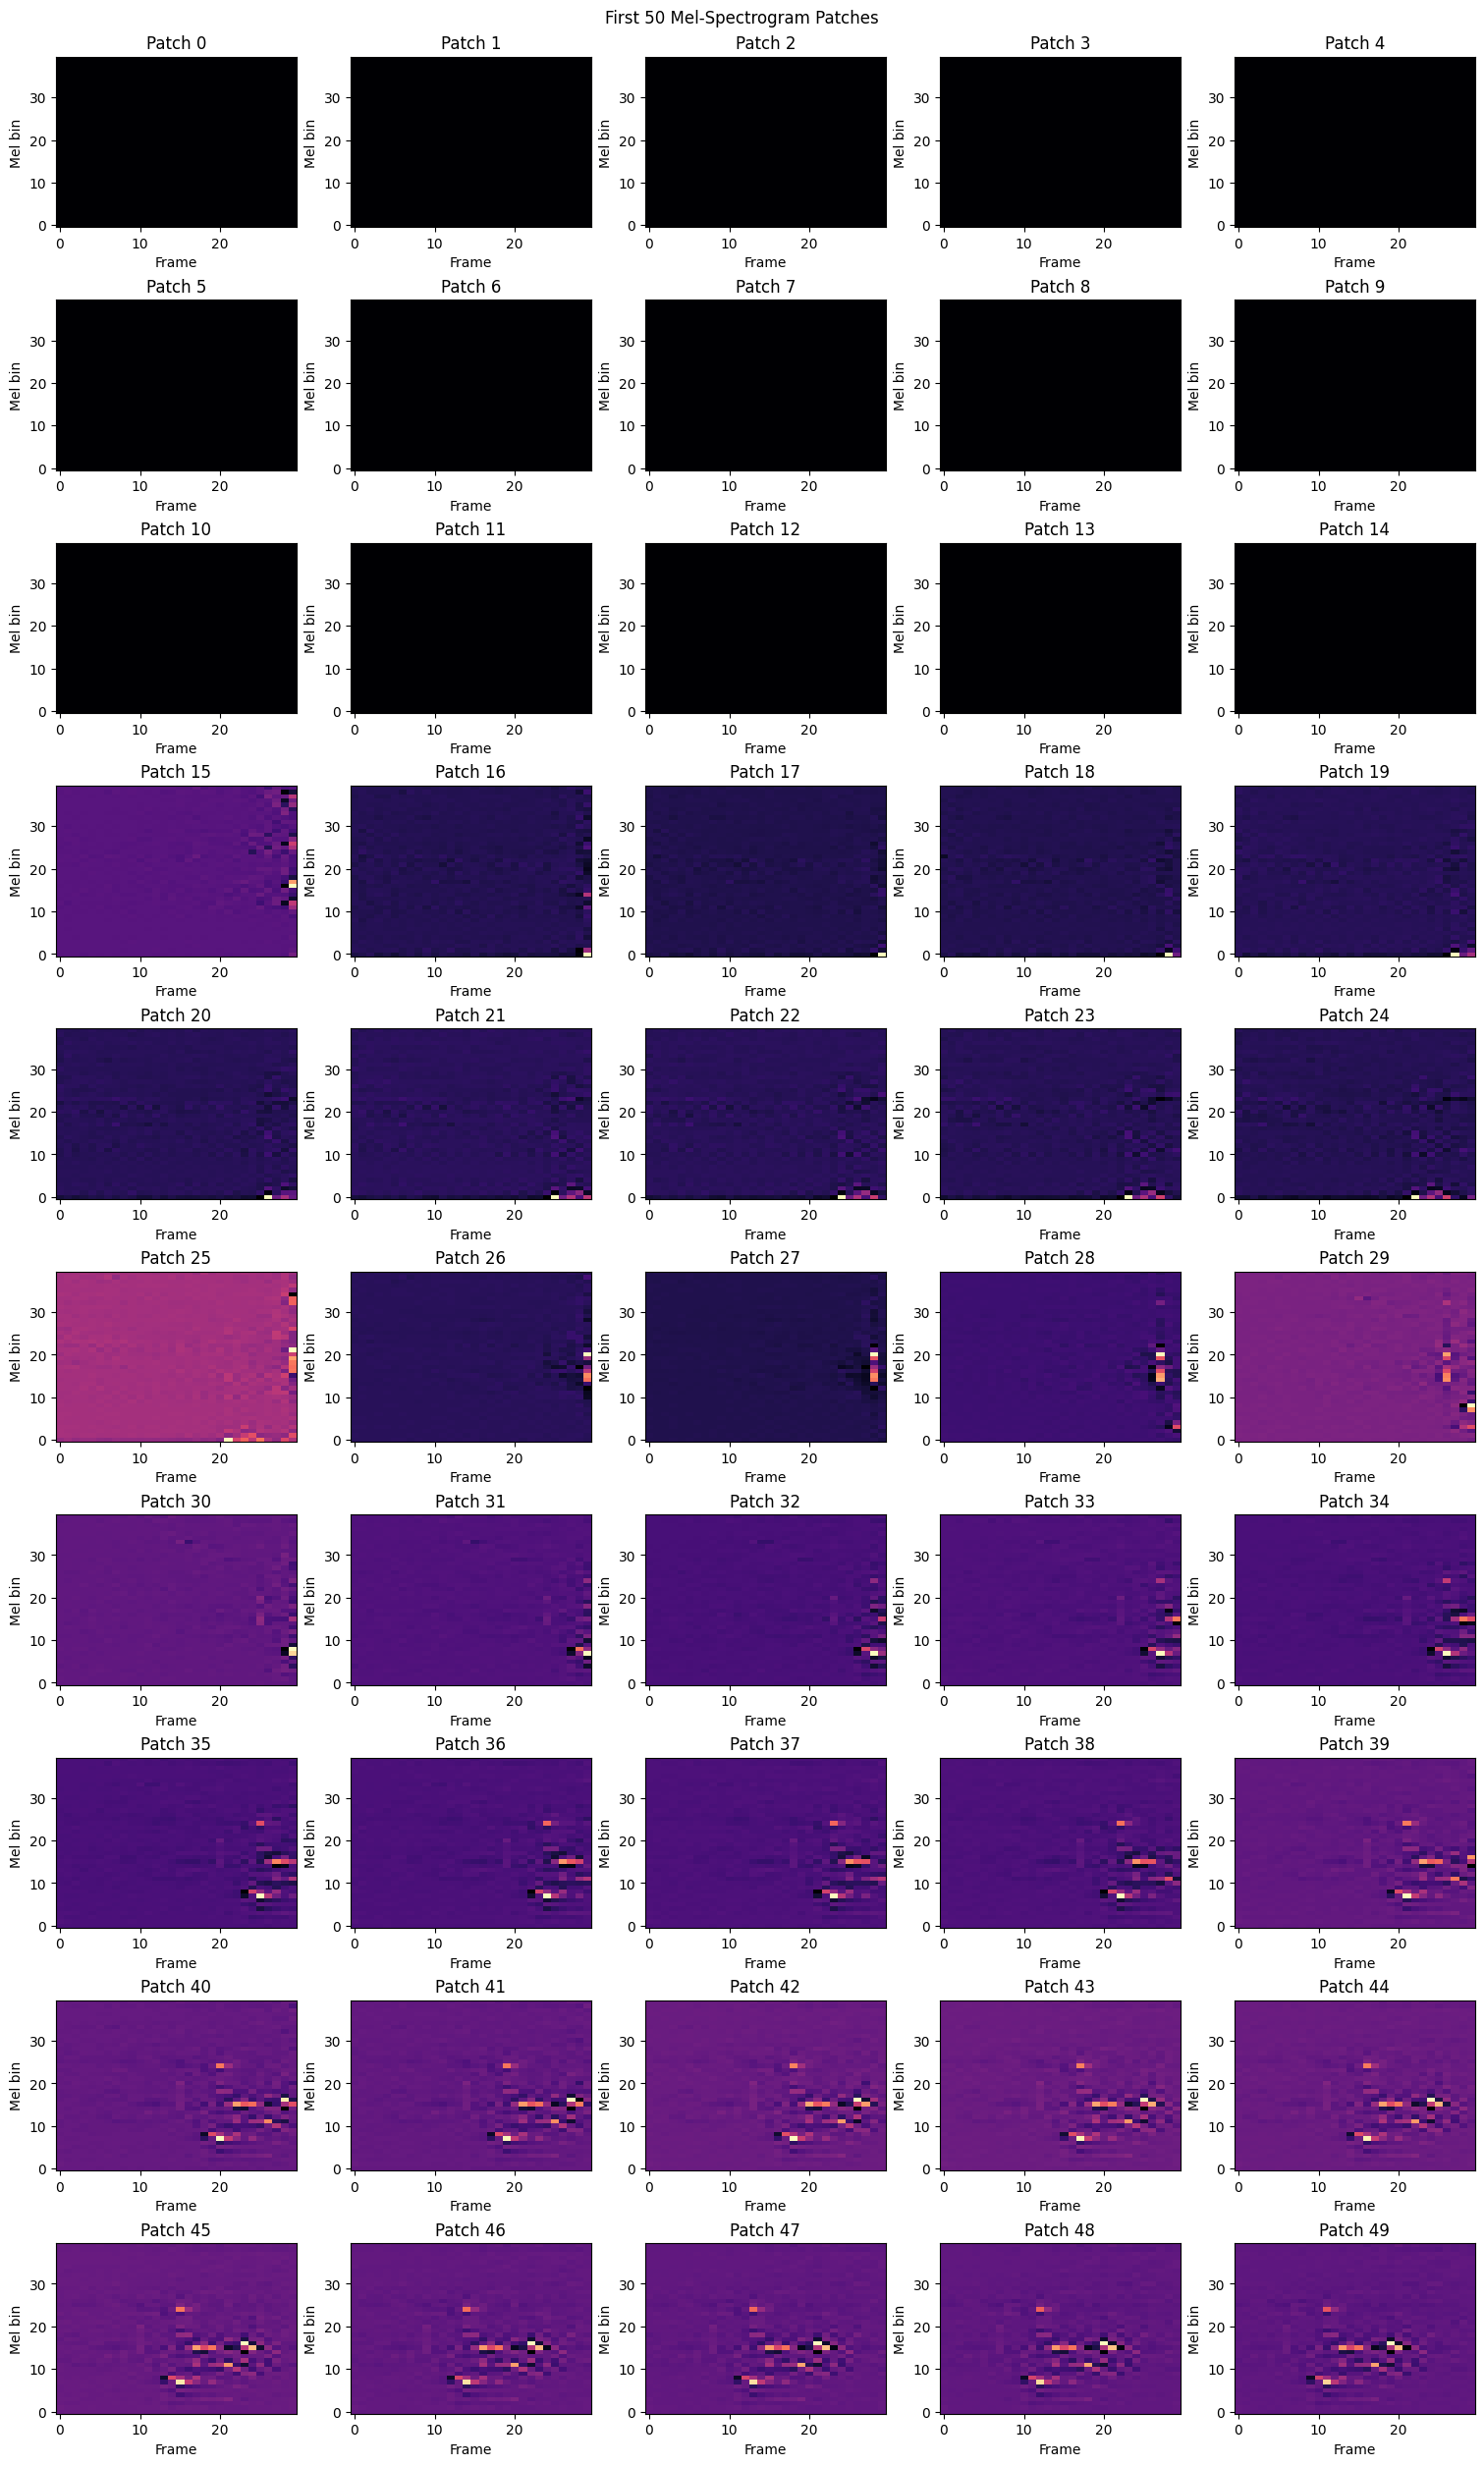

In [40]:
plot_first_n_mel_patches(norm_patches.reshape(norm_patches.shape[0], 40, 30), n_show=50, cols=5)

### sparse coding with kmeans on patches

In [64]:
kmeans=apply_kmeans_to_patches(norm_patches, 2000, sample_size=None)

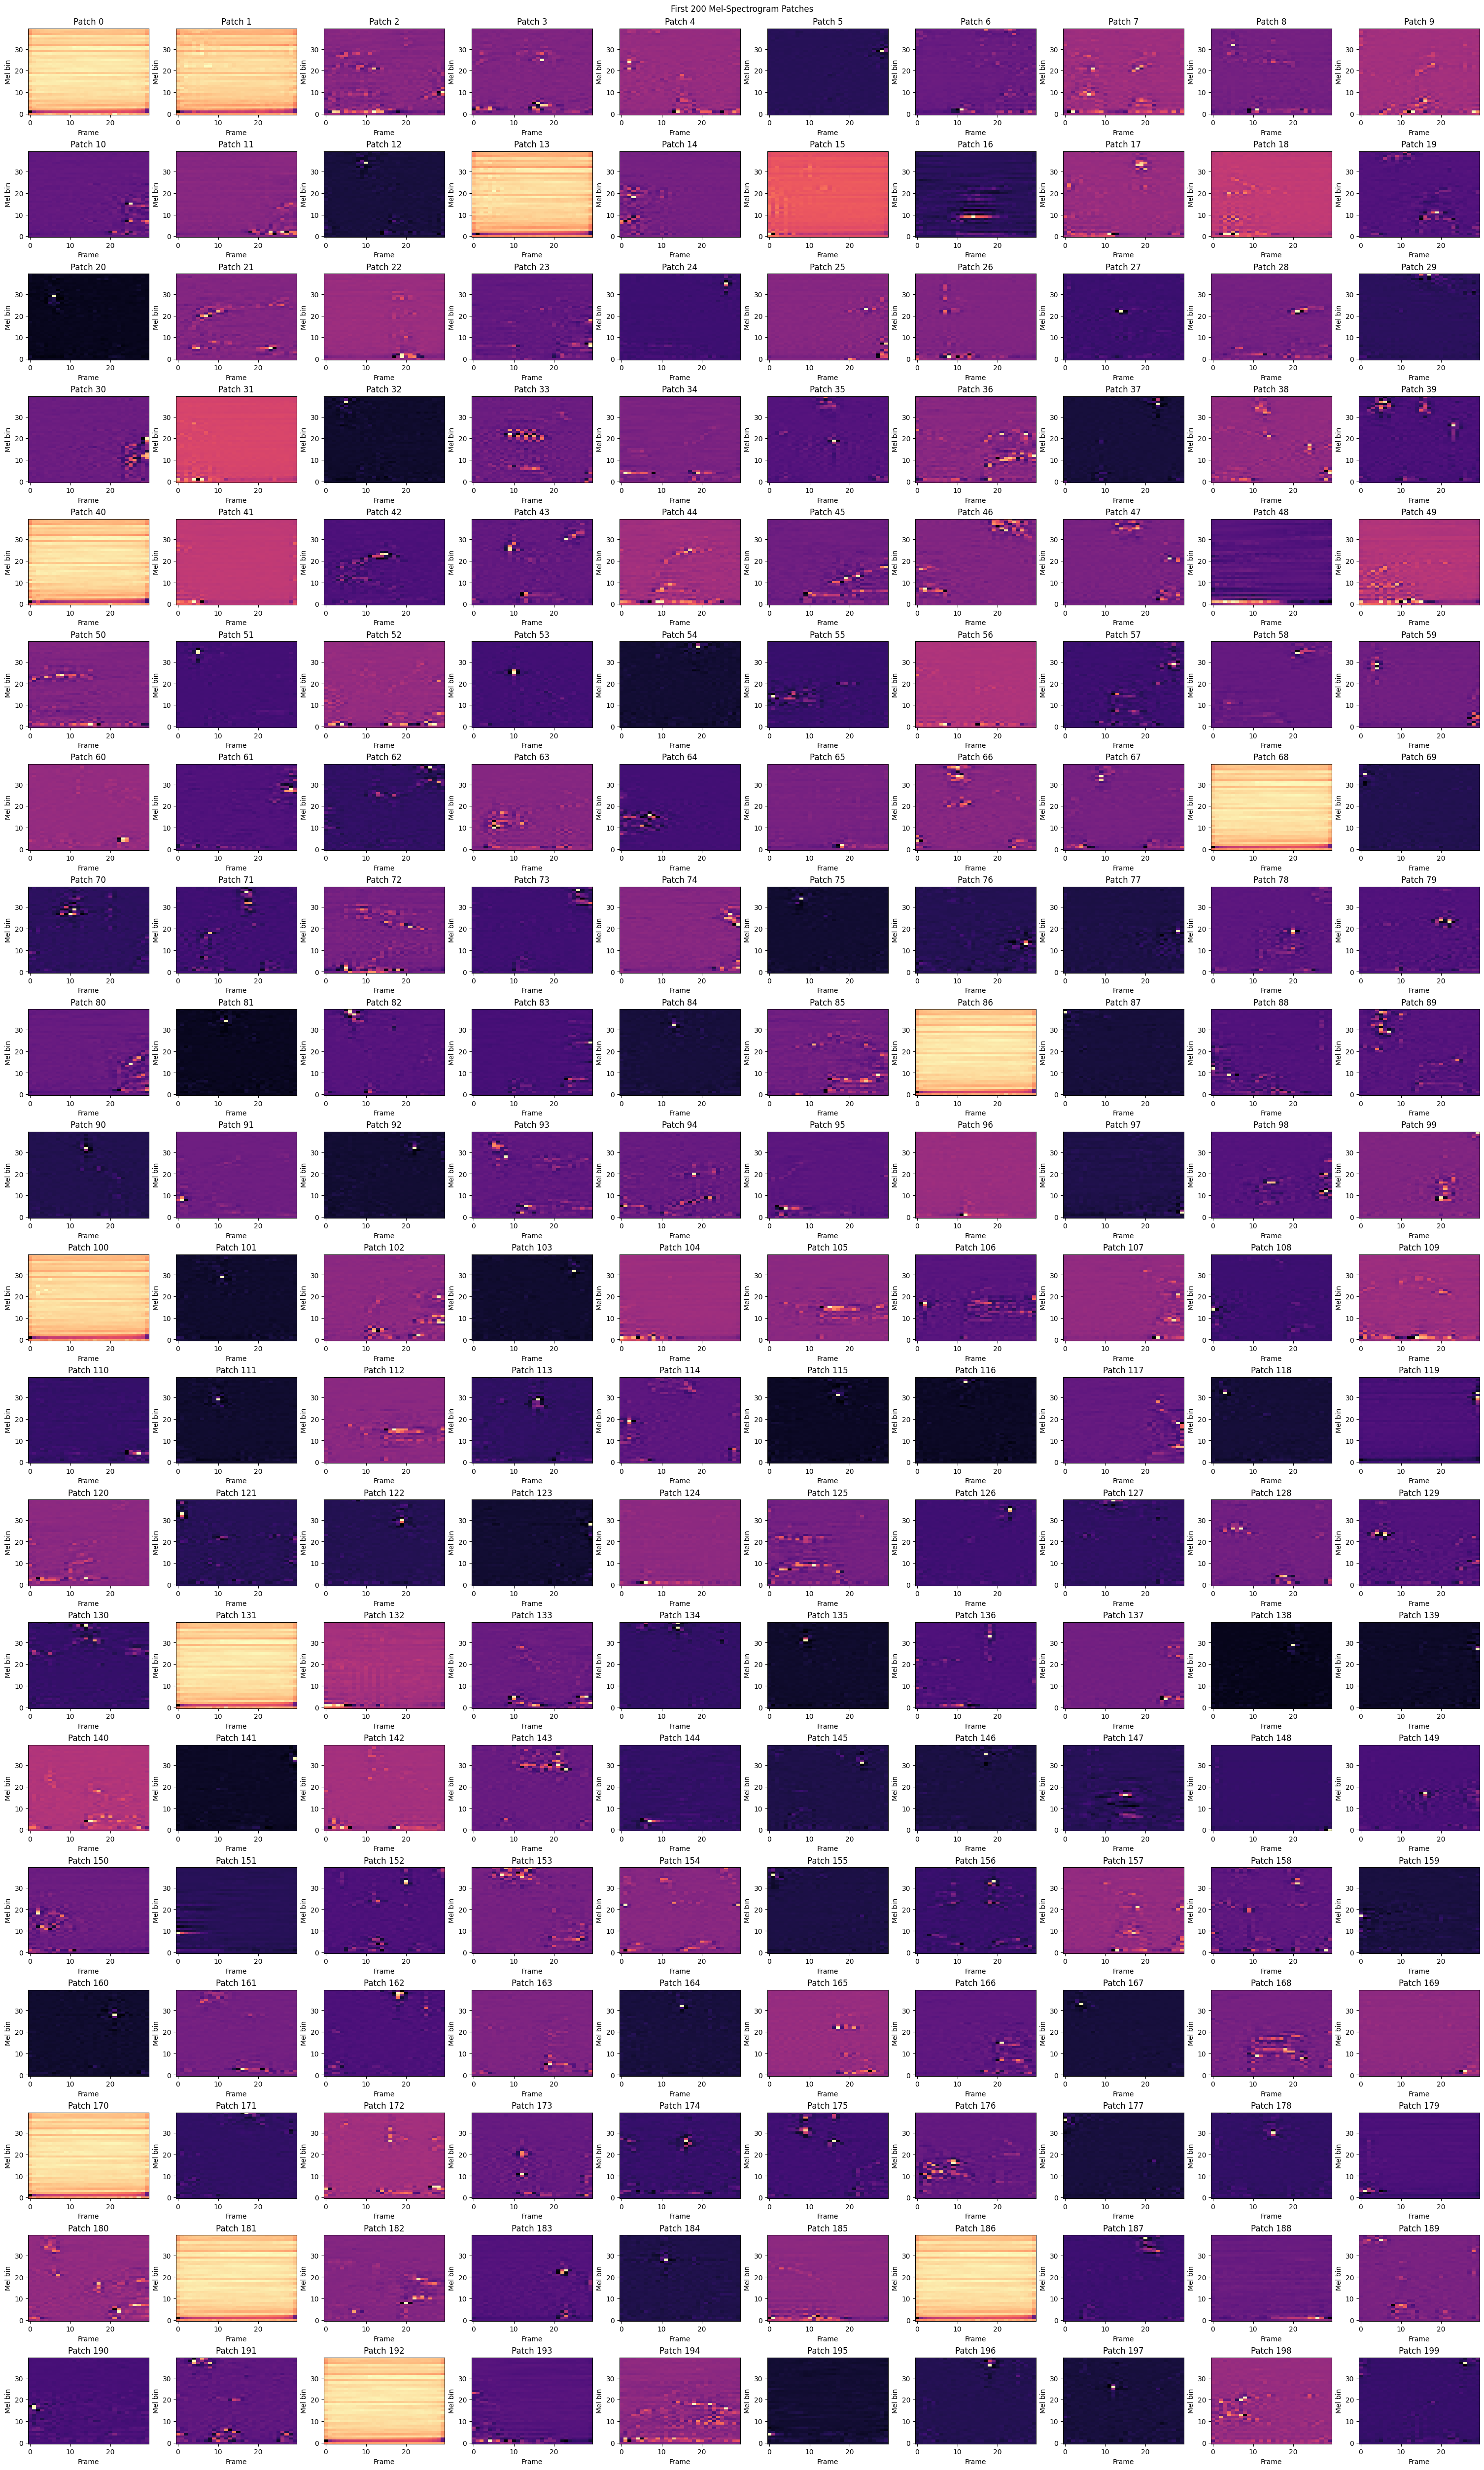

In [65]:
clusters = kmeans.cluster_centers_
clusters = clusters.reshape(clusters.shape[0],40,30)
plot_first_n_mel_patches(clusters, 200, 10)

### Spectral decomposition on the support (i.e. the clusters) 

In [66]:
labels = kmeans.labels_
n_clusters = kmeans.n_clusters 
eigvals, eigvecs = spectral_decomp(labels, utterance_bounds, n_clusters)

100%|██████████| 447/447 [00:00<00:00, 678.14it/s]


In [104]:
# take smallest 32 eigenvectors as P
d = 32  # embedding dimension
P = eigvecs[:, 1:d+1].T

### check for smooth trajectories in embedding space

In [105]:
n_samples = labels.shape[0]

# Sparse cluster code: shape (n_samples, n_clusters)
A = csr_matrix(
    (np.ones(n_samples, dtype=np.float32), (np.arange(n_samples), labels)),
    shape=(n_samples, n_clusters),
)

A = A.T

# "sense" the manifold with P
beta = P@A


In [106]:
# z-score beta
norm_beta, _, _ = preprocess_patches(beta.T) # this switches beta to be NxD like norm_patches
norm_beta = norm_beta

In [120]:
def calc_smoothness(data: np.ndarray):
    # assume data is NxD where N is the number of samples
    diff = np.diff(data, axis=0)
    diff_2 = np.diff(data, n=2, axis=0)

    grad_norm = np.linalg.norm(diff, ord=2, axis=1)
    grad_norm_2 = np.linalg.norm(diff_2, ord=2, axis=1)
    grad_median = np.median(grad_norm)
    grad_2_median = np.median(grad_norm_2)
    return grad_median, grad_2_median

def compare_smoothness_to_null(data: np.ndarray, null_dist_size: int = 1000):
    # assume data is NxD where N is the number of samples
    obs_grad_median, obs_grad_2_median = calc_smoothness(data)

    perm_grad_medians = []
    perm_grad_2_medians = []
    for i in range(null_dist_size):
        perm_data = data[np.random.permutation(data.shape[0]),:]
        perm_grad_median, perm_grad_2_median = calc_smoothness(perm_data)
        perm_grad_medians.append(perm_grad_median)
        perm_grad_2_medians.append(perm_grad_2_median)

    perm_grad_medians = np.array(perm_grad_medians)
    perm_grad_2_medians = np.array(perm_grad_2_medians)

    z_score_smooth = (obs_grad_median - np.mean(perm_grad_medians)) / np.std(perm_grad_medians)
    z_score_linear = (obs_grad_2_median - np.mean(perm_grad_2_medians)) / np.std(perm_grad_2_medians)
    return obs_grad_2_median, obs_grad_2_median, z_score_smooth, z_score_linear


In [117]:
# isolate single utterance
utterance = utterance_bounds[3]
sample_utterance_mel = norm_patches[utterance[0]:utterance[1],:]
sample_utterance_beta = norm_beta[utterance[0]:utterance[1],:]

# calc smoothness on sensed manifold and plot
obs_grad_median_beta, obs_grad_2_median_beta, z_score_smooth_beta, z_score_linear_beta = compare_smoothness_to_null(sample_utterance_beta)
obs_grad_median_mel, obs_grad_2_median_mel, z_score_smooth_mel, z_score_linear_mel = compare_smoothness_to_null(sample_utterance_mel)

100%|██████████| 1000/1000 [00:03<00:00, 315.70it/s]


In [122]:
beta_stats = {'obs_grad_median': [], 
             'obs_grad_2_median': [],
             'z_score_smooth': [],
             'z_score_linear': []}
mel_stats = {'obs_grad_median': [], 
             'obs_grad_2_median': [],
             'z_score_smooth': [],
             'z_score_linear': []}
for (start, end) in tqdm(utterance_bounds):
    sample_utterance_mel = norm_patches[start:end,:]
    sample_utterance_beta = norm_beta[start:end,:]

    # calc smoothness on sensed manifold and plot
    obs_grad_median_beta, obs_grad_2_median_beta, z_score_smooth_beta, z_score_linear_beta = compare_smoothness_to_null(sample_utterance_beta)
    beta_stats['obs_grad_median'].append(obs_grad_median_beta)
    beta_stats['obs_grad_2_median'].append(obs_grad_2_median_beta)
    beta_stats['z_score_smooth'].append(z_score_smooth_beta)
    beta_stats['z_score_linear'].append(z_score_linear_beta)
    
    obs_grad_median_mel, obs_grad_2_median_mel, z_score_smooth_mel, z_score_linear_mel = compare_smoothness_to_null(sample_utterance_mel)
    mel_stats['obs_grad_median'].append(obs_grad_median_mel)
    mel_stats['obs_grad_2_median'].append(obs_grad_2_median_mel)
    mel_stats['z_score_smooth'].append(z_score_smooth_mel)
    mel_stats['z_score_linear'].append(z_score_linear_mel)


  0%|          | 0/29 [00:00<?, ?it/s]

100%|██████████| 29/29 [01:20<00:00,  2.78s/it]


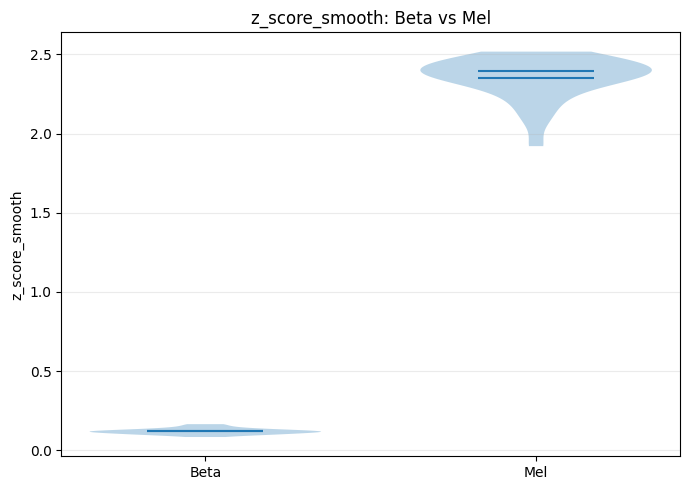

In [126]:
import numpy as np
import matplotlib.pyplot as plt

beta_z = np.asarray(beta_stats["obs_grad_2_median"])
mel_z  = np.asarray(mel_stats["obs_grad_2_median"])

fig, ax = plt.subplots(figsize=(7, 5))
parts = ax.violinplot(
    [beta_z, mel_z],
    positions=[1, 2],
    widths=0.7,
    showmeans=True,
    showmedians=True,
    showextrema=False,
)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Beta", "Mel"])
ax.set_ylabel("z_score_smooth")
ax.set_title("z_score_smooth: Beta vs Mel")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## Sparse coding using FISTA


In [ ]:
def quadraticBasisUpdate(basis, Res, ahat, lowestActivation, HessianDiag, stepSize = 0.001,constraint = 'L2', Noneg = False):
    """
    This matrix update the basis function based on the Hessian matrix of the activation.
    It's very similar to Newton method. But since the Hessian matrix of the activation function is often ill-conditioned, we takes the pseudo inverse.

    Note: currently, we can just use the inverse of the activation energy.
    A better idea for this method should be caculating the local Lipschitz constant for each of the basis.
    The stepSize should be smaller than 1.0 * min(activation) to be stable.
    """
    dBasis = stepSize*torch.mm(Res, ahat.t())/ahat.size(1)
    dBasis = dBasis.div_(HessianDiag+lowestActivation)
    basis = basis.add_(dBasis)
    if Noneg:
        basis = basis.clamp(min = 0.)
    if constraint == 'L2':
        basis = basis.div_(basis.norm(2,0))
    return basis
    
def FISTA(I,basis,lambd,num_iter,eta=None, useMAGMA=True):
    # This is a positive-only PyTorch-Ver FISTA solver
    dtype = basis.type()
    batch_size=I.size(1)
    M = basis.size(1)
    if eta is None:
        if useMAGMA:
            L = torch.max(torch.symeig(torch.mm(basis,basis.t()),eigenvectors=False)[0])
            eta = 1./L
        else:
            eta = 1./cp.linalg.eigvalsh(cp.asarray(torch.mm(basis,basis.t()).cpu().numpy())).max().get().reshape(1)
            eta = torch.from_numpy(eta.astype('float32')).cuda()

    tk_n = 1.
    tk = 1.
    Res = torch.cuda.FloatTensor(I.size()).fill_(0)
    ahat = torch.cuda.FloatTensor(M,batch_size).fill_(0)
    ahat_y = torch.cuda.FloatTensor(M,batch_size).fill_(0)

    for t in range(num_iter):
        tk = tk_n
        tk_n = (1+np.sqrt(1+4*tk**2))/2
        ahat_pre = ahat
        Res = I - torch.mm(basis,ahat_y)
        ahat_y = ahat_y.add(eta * basis.t().mm(Res))
        ahat = ahat_y.sub(eta * lambd).clamp(min = 0.)
        ahat_y = ahat.add(ahat.sub(ahat_pre).mul((tk-1)/(tk_n)))
    Res = I - torch.mm(basis,ahat)
    return ahat, Res